# Dataset Download, Audit, and Research Design

This notebook establishes the reproducible experimental foundation for Bayesian temporal graph overload-risk forecasting in power transmission grids. It creates the project directories, verifies the Zenodo data source, extracts the raw archives without modifying them, audits file-level and network-level properties, defines leakage controls, and stores the experiment configuration used by the downstream notebooks.

In [1]:
import os, json, math, time, zipfile, subprocess, warnings, textwrap, hashlib
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 17,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.dpi": 350,
    "figure.dpi": 350,
})

PALETTE = {
    "blue": "#2F6B8F",
    "orange": "#C77C2B",
    "green": "#4F7F3A",
    "purple": "#6D5A8D",
    "red": "#B45A55",
    "gray": "#6E7378",
    "light_gray": "#E7EAED",
    "teal": "#4A8C8A",
    "gold": "#C9A227",
    "black": "#222222",
    "white": "#FFFFFF",
}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW = PROJECT_ROOT / "Data" / "Raw"
DATA_UNIFIED = PROJECT_ROOT / "Data" / "Unified"
DATA_EXTERNAL = PROJECT_ROOT / "Data" / "External_Test"
TABLES = PROJECT_ROOT / "Tables"
FIGURES = PROJECT_ROOT / "Figures"
MODELS = PROJECT_ROOT / "Models"
REPORTS = PROJECT_ROOT / "Reports"
for p in [DATA_RAW, DATA_UNIFIED, DATA_EXTERNAL, TABLES, FIGURES, MODELS, REPORTS, PROJECT_ROOT / "Drawio_Preview"]:
    p.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Random seed: {RANDOM_SEED}")

Project root: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1
Random seed: 42


## Dataset Acquisition Protocol

The executable default uses the 2020 load, generation, and line-flow groups from the Zenodo record. The notebook is written so matching yearly groups can be enabled later, but the current run uses 2020 because the compressed 2020 archives already exceed 3 GB and provide four matched suffix groups for internal and external testing.

In [2]:
RECORD_ID = "13378476"
BASE_URL = f"https://zenodo.org/records/{RECORD_ID}/files"
YEARS = [2020]
ENABLE_MULTIYEAR = False
required_files = ["europe_network.json"]
for year in YEARS:
    required_files += [f"loads_{year}.zip", f"gens_{year}.zip", f"lines_{year}.zip"]

expected_min_bytes = {
    "europe_network.json": 1_000_000,
    "loads_2020.zip": 1_000_000_000,
    "gens_2020.zip": 100_000_000,
    "lines_2020.zip": 1_500_000_000,
}

def download_if_missing(fname):
    local_path = DATA_RAW / fname
    url = f"{BASE_URL}/{fname}?download=1"
    status = "exists"
    if not local_path.exists() or local_path.stat().st_size == 0:
        status = "downloaded"
        cmd = ["wget", "-O", str(local_path), url]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, check=True)
    size = local_path.stat().st_size if local_path.exists() else 0
    ok = size >= expected_min_bytes.get(fname, 1)
    return {
        "source_url": url,
        "local_path": str(local_path.relative_to(PROJECT_ROOT)),
        "file_size_bytes": size,
        "download_status": status if ok else "failed_size_check",
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }

manifest = pd.DataFrame([download_if_missing(f) for f in required_files])
manifest.to_csv(TABLES / "download_manifest.csv", index=False)
manifest.to_csv(DATA_RAW / "download_manifest.csv", index=False)
display(manifest)
print("Saved:", TABLES / "download_manifest.csv")

,source_url,local_path,file_size_bytes,download_status,timestamp_utc
0,https://zenodo.org/records/13378476/files/euro...,Data/Raw/europe_network.json,4331482,exists,2026-05-20T18:59:08.945215+00:00
1,https://zenodo.org/records/13378476/files/load...,Data/Raw/loads_2020.zip,1280351867,exists,2026-05-20T18:59:08.945418+00:00
2,https://zenodo.org/records/13378476/files/gens...,Data/Raw/gens_2020.zip,125820756,exists,2026-05-20T18:59:08.945567+00:00
3,https://zenodo.org/records/13378476/files/line...,Data/Raw/lines_2020.zip,2145457640,exists,2026-05-20T18:59:08.945773+00:00


Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Tables/download_manifest.csv


## Raw Archive Extraction

Raw ZIP files are retained unchanged. Extraction is performed into clear subfolders under `Data/Raw/` only when the expected CSV members are not already present.

In [3]:
def extract_zip_if_needed(zip_path):
    extract_dir = DATA_RAW / zip_path.stem
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        members = zf.namelist()
        missing = [m for m in members if not (extract_dir / m).exists()]
        if missing:
            print(f"Extracting {zip_path.name} to {extract_dir.relative_to(PROJECT_ROOT)}")
            zf.extractall(extract_dir)
        else:
            print(f"Extraction already present for {zip_path.name}")
    return extract_dir, members

extraction_rows = []
for zip_path in sorted(DATA_RAW.glob("*.zip")):
    extract_dir, members = extract_zip_if_needed(zip_path)
    extraction_rows.append({
        "archive": zip_path.name,
        "extract_dir": str(extract_dir.relative_to(PROJECT_ROOT)),
        "member_count": len(members),
        "members": "; ".join(members),
    })
extraction_df = pd.DataFrame(extraction_rows)
display(extraction_df)

Extraction already present for gens_2020.zip
Extraction already present for lines_2020.zip
Extraction already present for loads_2020.zip


,archive,extract_dir,member_count,members
0,gens_2020.zip,Data/Raw/gens_2020,4,gens_2020_1.csv; gens_2020_2.csv; gens_2020_3....
1,lines_2020.zip,Data/Raw/lines_2020,4,lines_2020_1.csv; lines_2020_2.csv; lines_2020...
2,loads_2020.zip,Data/Raw/loads_2020,4,loads_2020_1.csv; loads_2020_2.csv; loads_2020...


## File-Level Audit

The audit records row counts, column counts, missing values in a sample, numeric ranges, suffix groups, and matching status. Matching is performed only between load, generation, and line-flow files with the same year and suffix.

In [4]:
def fast_line_count(path):
    out = subprocess.check_output(["wc", "-l", str(path)], text=True).strip().split()[0]
    return int(out)

def summarize_csv(path):
    header = pd.read_csv(path, nrows=0)
    sample = pd.read_csv(path, nrows=250, dtype=np.float32)
    parts = path.stem.split("_")
    kind = parts[0]
    year = int(parts[1])
    suffix = parts[2] if len(parts) > 2 else "none"
    values = sample.to_numpy(dtype=np.float32, copy=False)
    return {
        "file": str(path.relative_to(PROJECT_ROOT)),
        "kind": kind,
        "year": year,
        "suffix": suffix,
        "rows": fast_line_count(path) - 1,
        "columns": len(header.columns),
        "sample_missing_values": int(sample.isna().sum().sum()),
        "sample_min": float(np.nanmin(values)),
        "sample_max": float(np.nanmax(values)),
        "sample_mean": float(np.nanmean(values)),
        "size_bytes": path.stat().st_size,
    }

csv_paths = sorted(DATA_RAW.glob("*_2020/*_2020_*.csv"))
file_summary = pd.DataFrame([summarize_csv(p) for p in csv_paths])
file_summary.to_csv(TABLES / "dataset_file_summary.csv", index=False)

pivot = file_summary.pivot_table(index=["year", "suffix"], columns="kind", values="file", aggfunc="count", fill_value=0).reset_index()
for col in ["loads", "gens", "lines"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot["matched_load_gen_line_group"] = (pivot["loads"].eq(1) & pivot["gens"].eq(1) & pivot["lines"].eq(1))
print("Matched suffix groups:")
display(pivot)
display(file_summary)
print("Saved:", TABLES / "dataset_file_summary.csv")

Matched suffix groups:


kind,year,suffix,gens,lines,loads,matched_load_gen_line_group
0,2020,1,1,1,1,True
1,2020,2,1,1,1,True
2,2020,3,1,1,1,True
3,2020,4,1,1,1,True


,file,kind,year,suffix,rows,columns,sample_missing_values,sample_min,sample_max,sample_mean,size_bytes
0,Data/Raw/gens_2020/gens_2020_1.csv,gens,2020,1,8736,815,0,0.000000,50.880001,2.634456,82483939
1,Data/Raw/gens_2020/gens_2020_2.csv,gens,2020,2,8736,815,0,0.000000,50.880001,2.632504,81981984
2,Data/Raw/gens_2020/gens_2020_3.csv,gens,2020,3,8736,815,0,0.000000,50.880001,2.631701,82192788
3,Data/Raw/gens_2020/gens_2020_4.csv,gens,2020,4,8736,815,0,0.000000,50.880001,2.623322,82059521
4,Data/Raw/lines_2020/lines_2020_1.csv,lines,2020,1,8736,8375,0,-26.210764,22.319695,-0.006071,1444399165
5,Data/Raw/lines_2020/lines_2020_2.csv,lines,2020,2,8736,8375,0,-25.709927,22.709206,-0.005338,1444327857
6,Data/Raw/lines_2020/lines_2020_3.csv,lines,2020,3,8736,8375,0,-25.698883,24.252686,-0.005822,1444369322
7,Data/Raw/lines_2020/lines_2020_4.csv,lines,2020,4,8736,8375,0,-23.815607,20.661716,-0.005031,1444411447
8,Data/Raw/loads_2020/loads_2020_1.csv,loads,2020,1,8736,4097,0,-0.127071,6.868115,0.524062,695438289
9,Data/Raw/loads_2020/loads_2020_2.csv,loads,2020,2,8736,4097,0,-0.199130,6.849415,0.523674,695428141


Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Tables/dataset_file_summary.csv


## Network Topology Audit

The static network JSON is parsed to quantify buses, branches, generators, loads, capacities, voltage levels, and generator types. These components later define topology-aware line features and graph-neighborhood aggregation.

In [5]:
network_path = DATA_RAW / "europe_network.json"
with open(network_path) as f:
    network = json.load(f)
component_rows = []
for key in ["bus", "branch", "gen", "load", "dcline", "storage", "switch", "shunt"]:
    obj = network.get(key, {})
    component_rows.append({"component": key, "count": len(obj) if hasattr(obj, "__len__") else np.nan})
network_component_summary = pd.DataFrame(component_rows)

branch_df = pd.DataFrame(network["branch"].values())
gen_df = pd.DataFrame(network["gen"].values())
bus_df = pd.DataFrame(network["bus"].values())
load_meta_df = pd.DataFrame(network["load"].values())
extra_rows = pd.DataFrame([
    {"component": "branch_rate_a_min", "count": float(pd.to_numeric(branch_df.get("rate_a"), errors="coerce").min())},
    {"component": "branch_rate_a_median", "count": float(pd.to_numeric(branch_df.get("rate_a"), errors="coerce").median())},
    {"component": "branch_rate_a_max", "count": float(pd.to_numeric(branch_df.get("rate_a"), errors="coerce").max())},
    {"component": "generator_type_count", "count": int(gen_df.get("type", pd.Series(dtype=object)).nunique())},
    {"component": "country_count", "count": int(bus_df.get("country", pd.Series(dtype=object)).nunique())},
])
network_component_summary = pd.concat([network_component_summary, extra_rows], ignore_index=True)
network_component_summary.to_csv(TABLES / "network_component_summary.csv", index=False)
display(network_component_summary)
print("Generator types:")
display(gen_df.get("type", pd.Series(dtype=object)).value_counts().rename_axis("type").reset_index(name="count").head(20))
print("Saved:", TABLES / "network_component_summary.csv")

,component,count
0,bus,4097.0
1,branch,8375.0
2,gen,815.0
3,load,4097.0
4,dcline,0.0
5,storage,0.0
6,switch,0.0
7,shunt,0.0
8,branch_rate_a_min,1.4
9,branch_rate_a_median,4.9


Generator types:


,type,count
0,hydro_ror,193
1,fossil_coal_gas,127
2,fossil_brown_lignite,101
3,fossil_oil,53
4,hydro_pure_storage,50
5,Hydro,43
6,nuclear,42
7,hydro_pure_ps,41
8,fossil_coal_hard,41
9,hydro_mixed,40


Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Tables/network_component_summary.csv


## Raw Data Visual Audit

The following figures summarize data coverage, network component scale, and the raw line-flow distribution from a representative sample. The line-flow plot uses raw values only and is not used for model tuning.

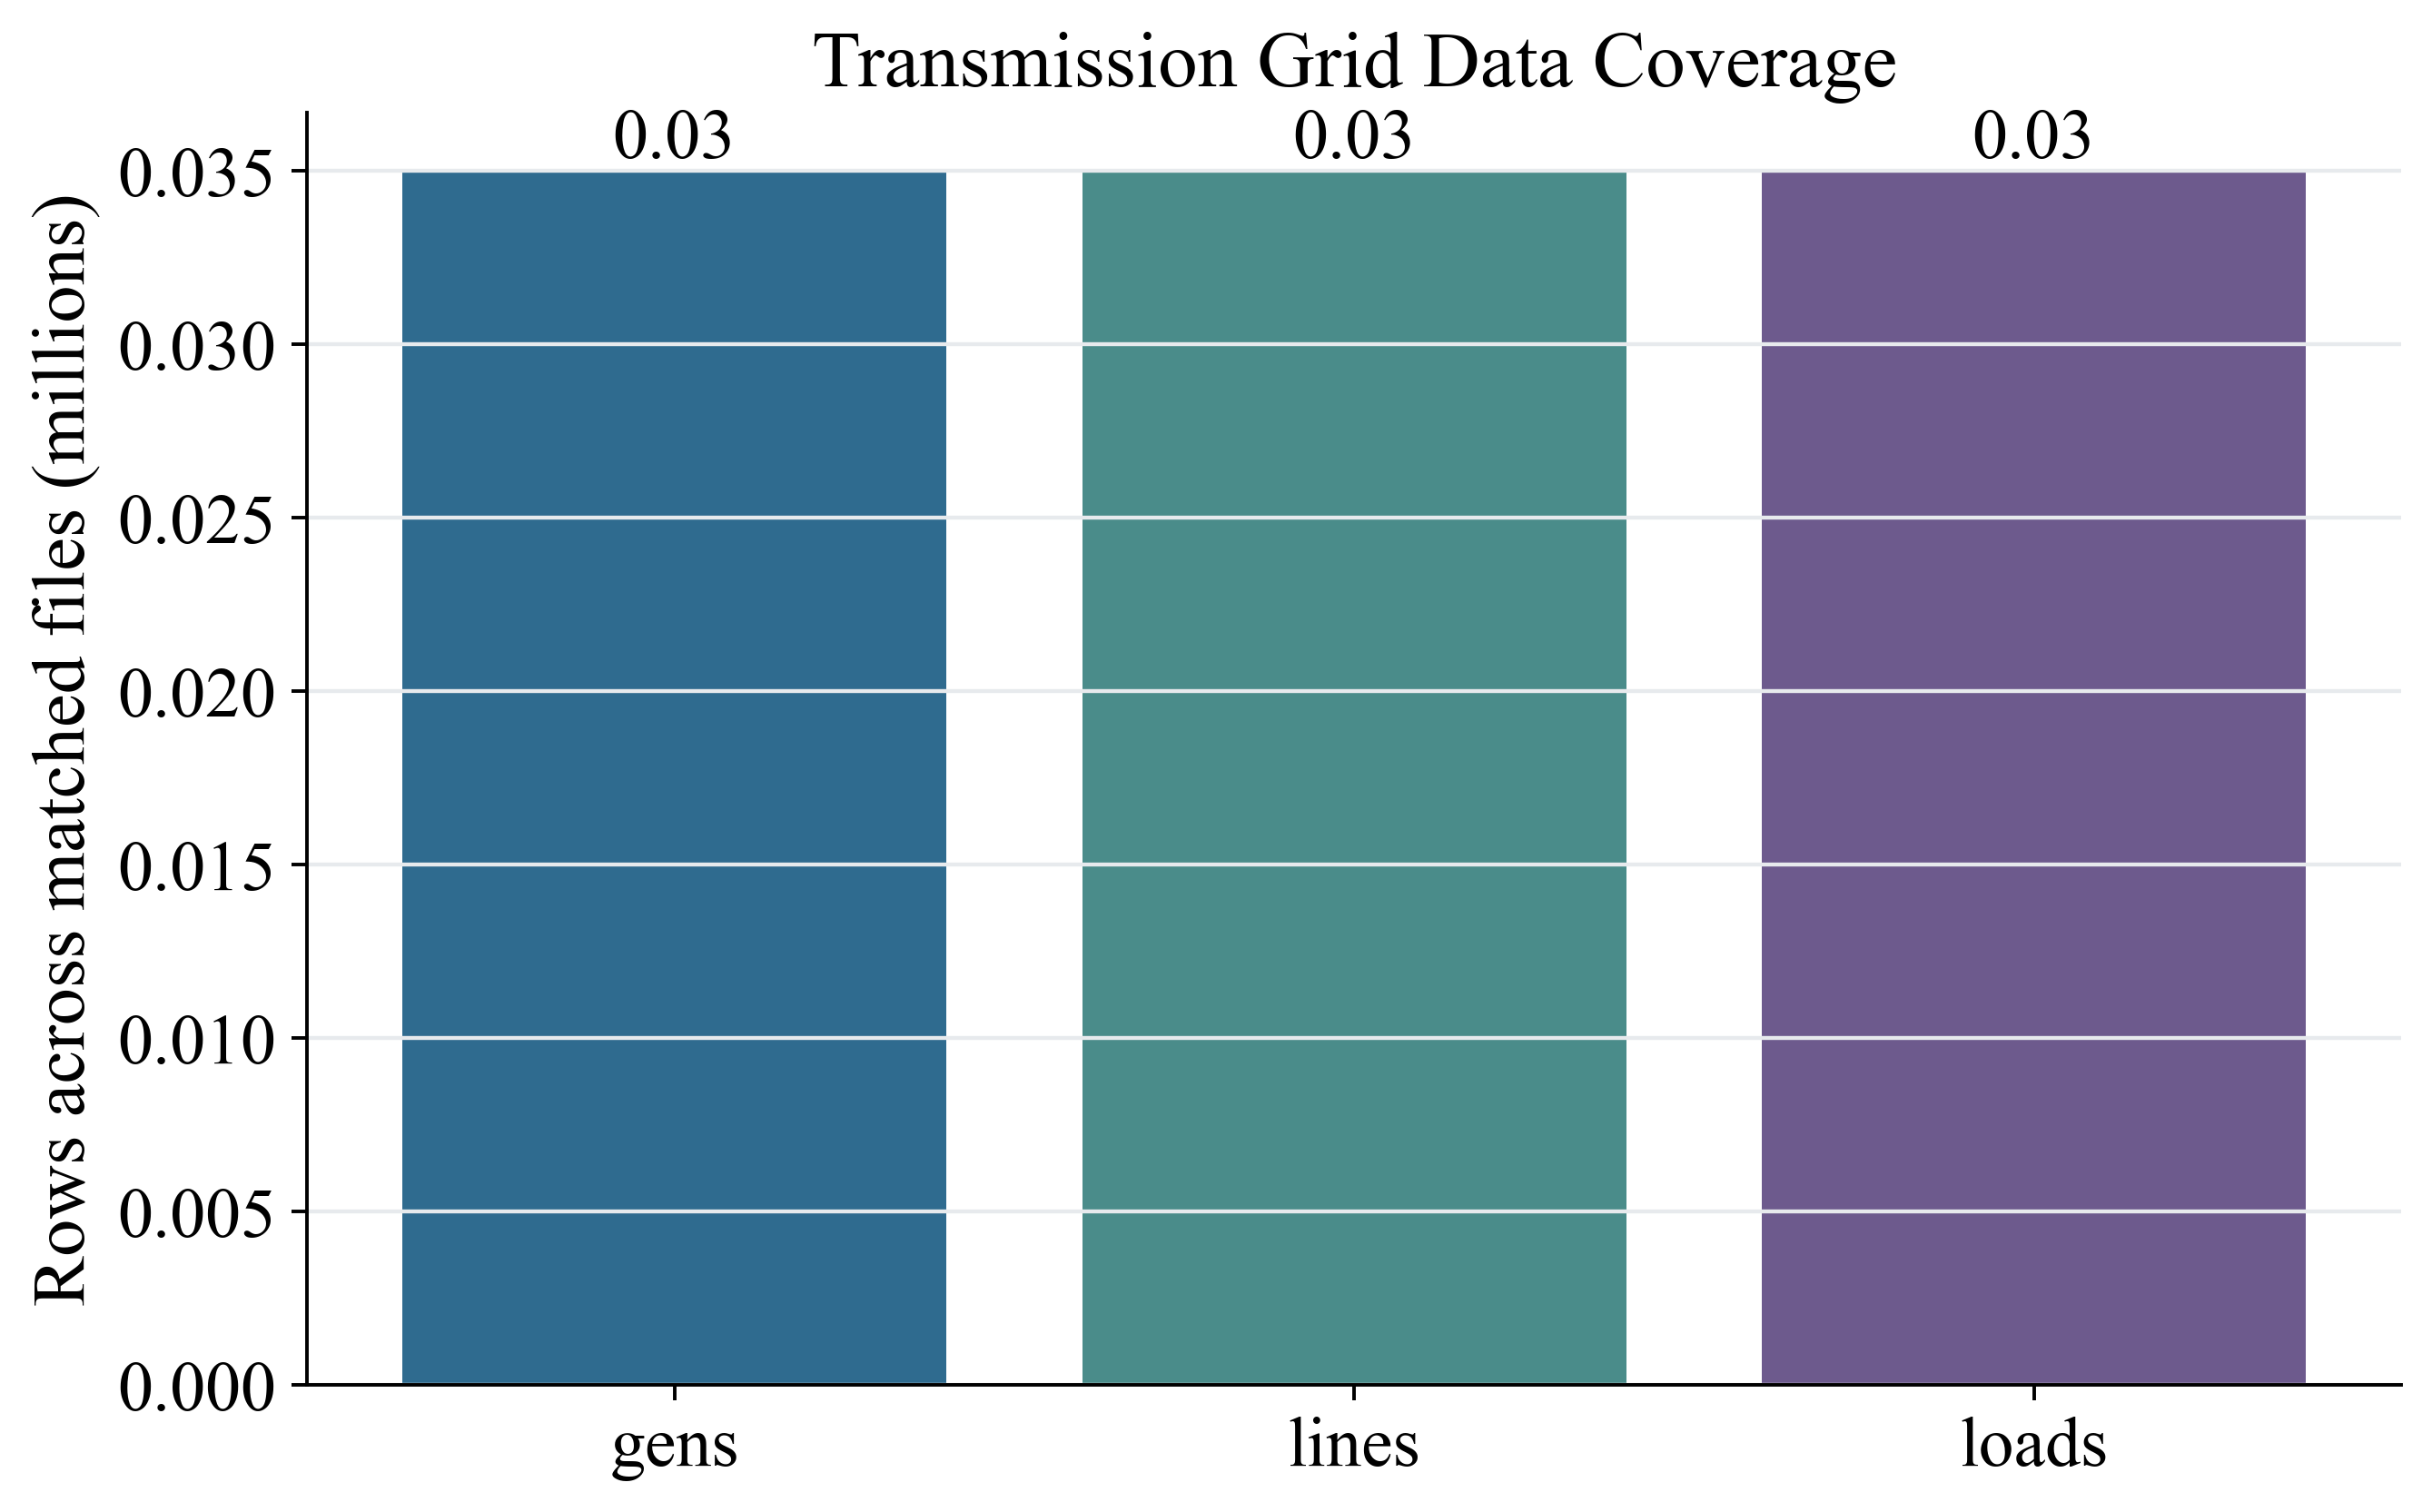

Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Figures/fig_01_data_coverage.png


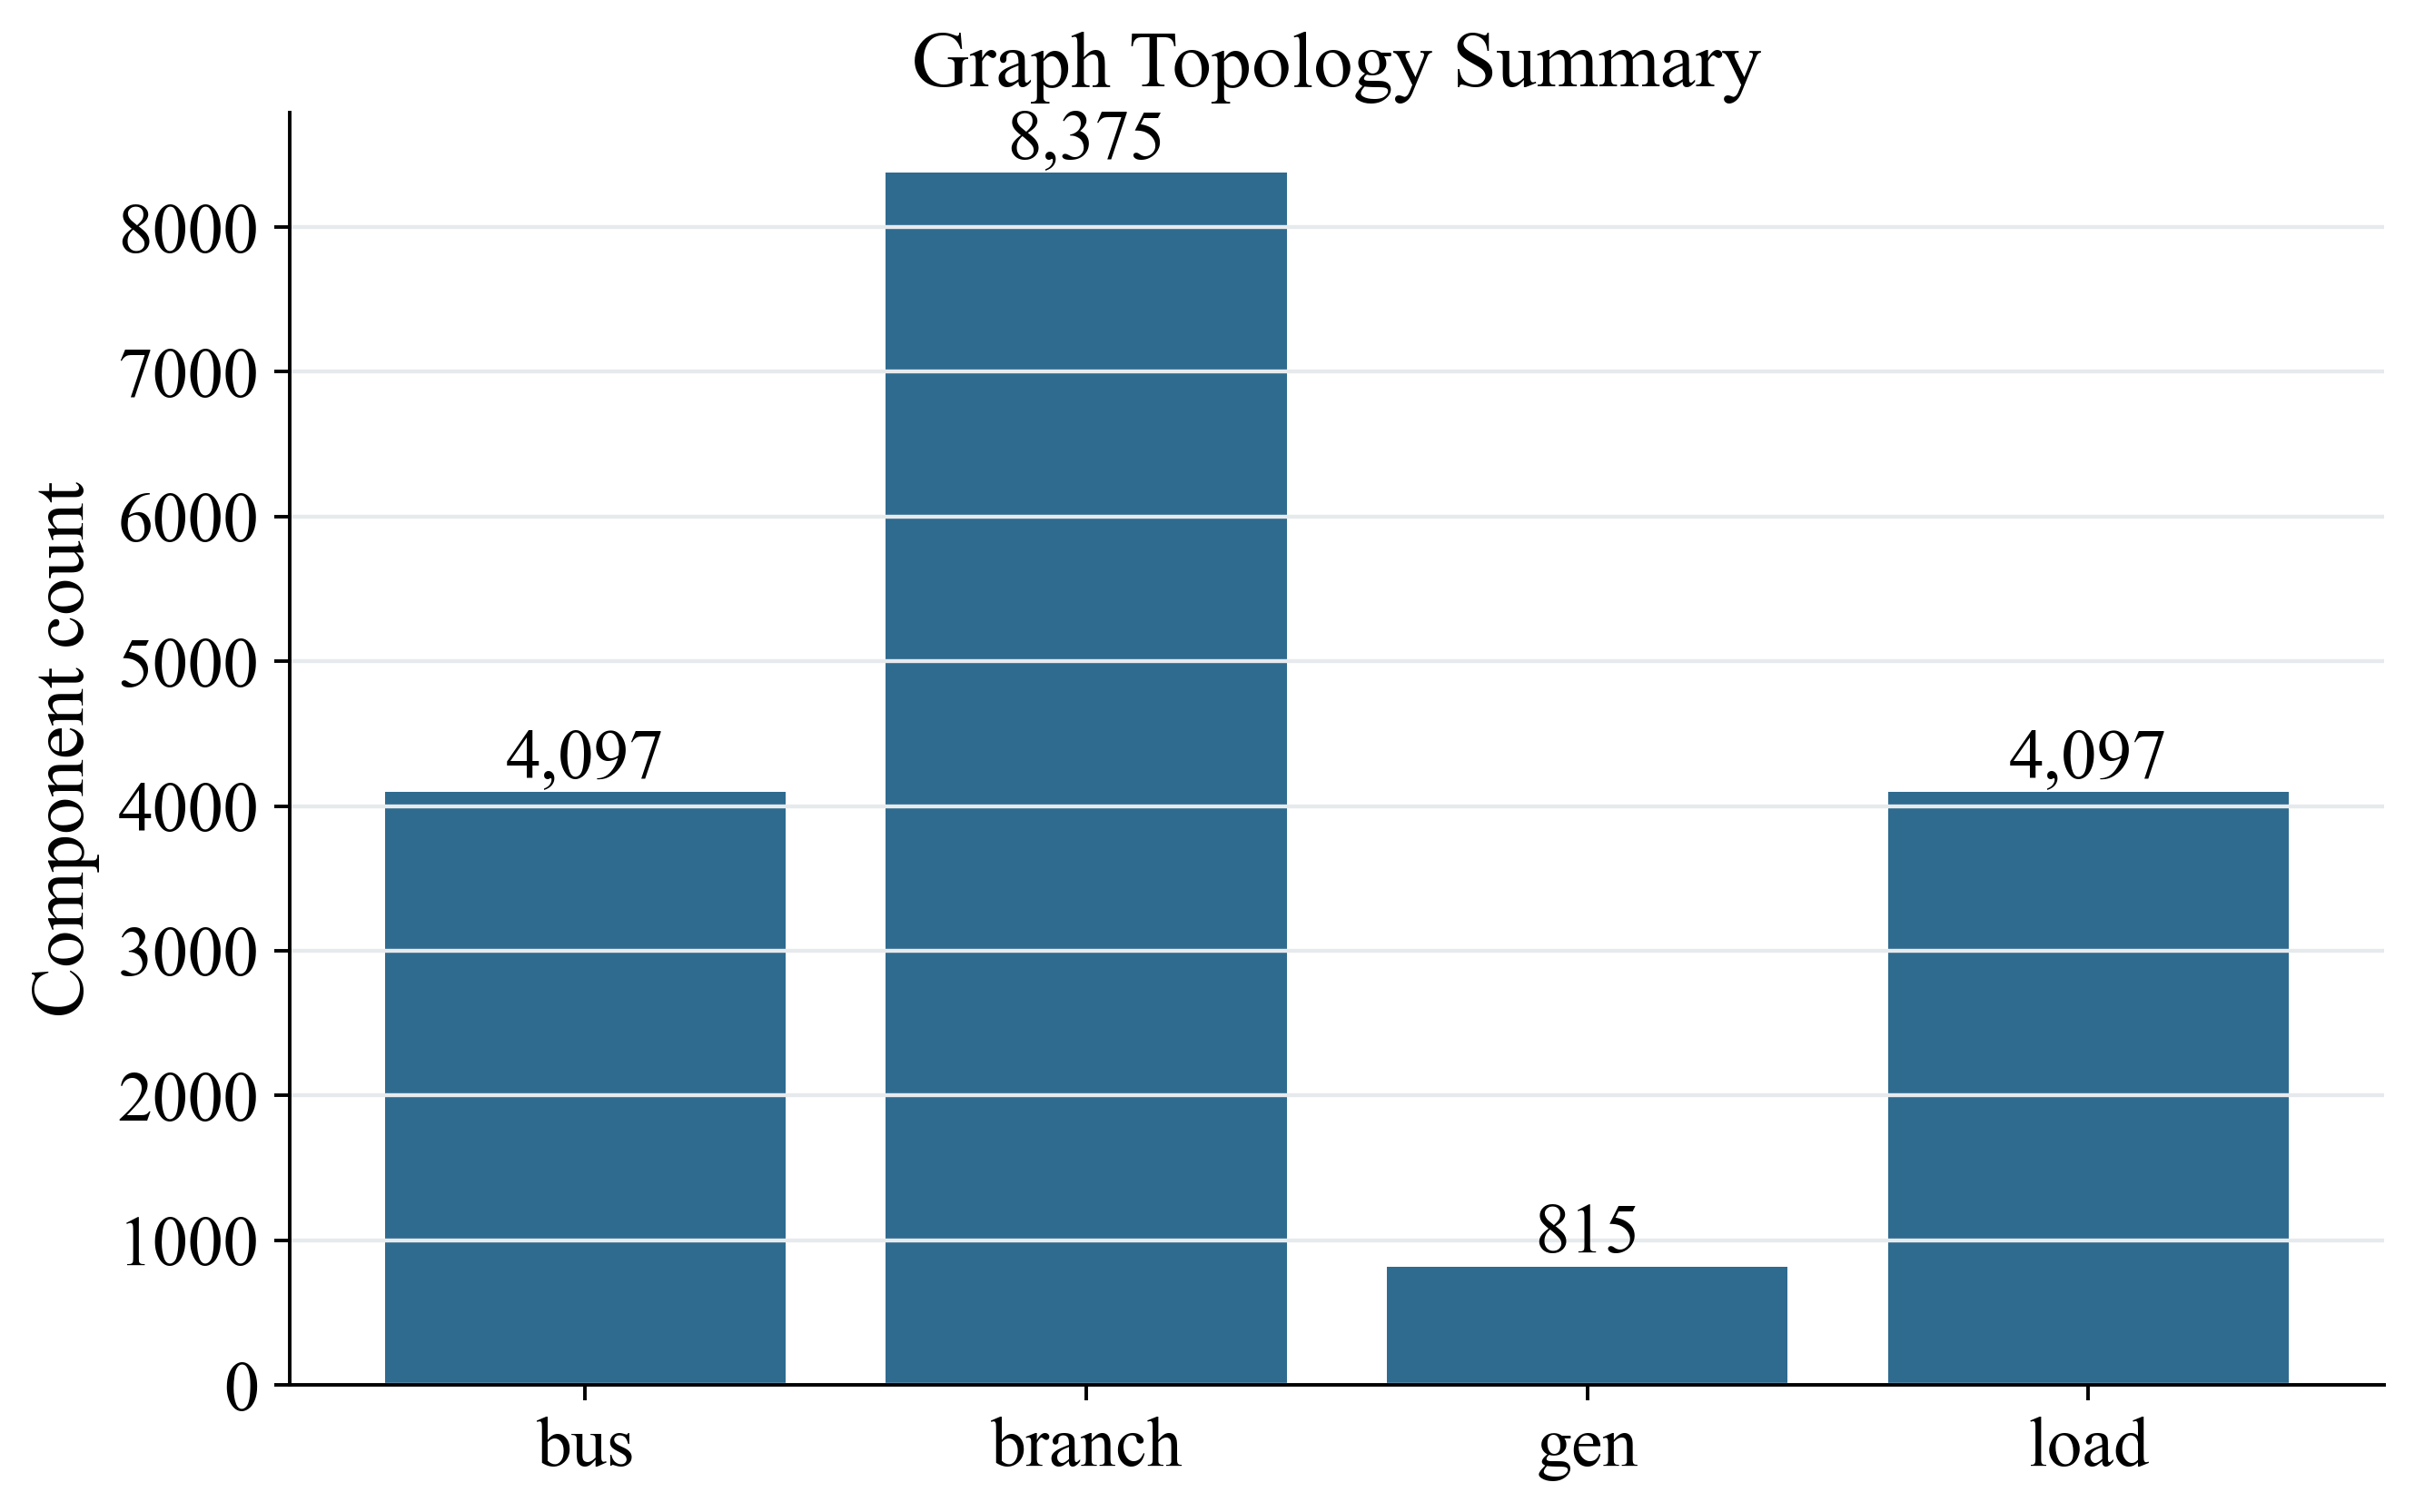

Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Figures/fig_02_network_component_summary.png


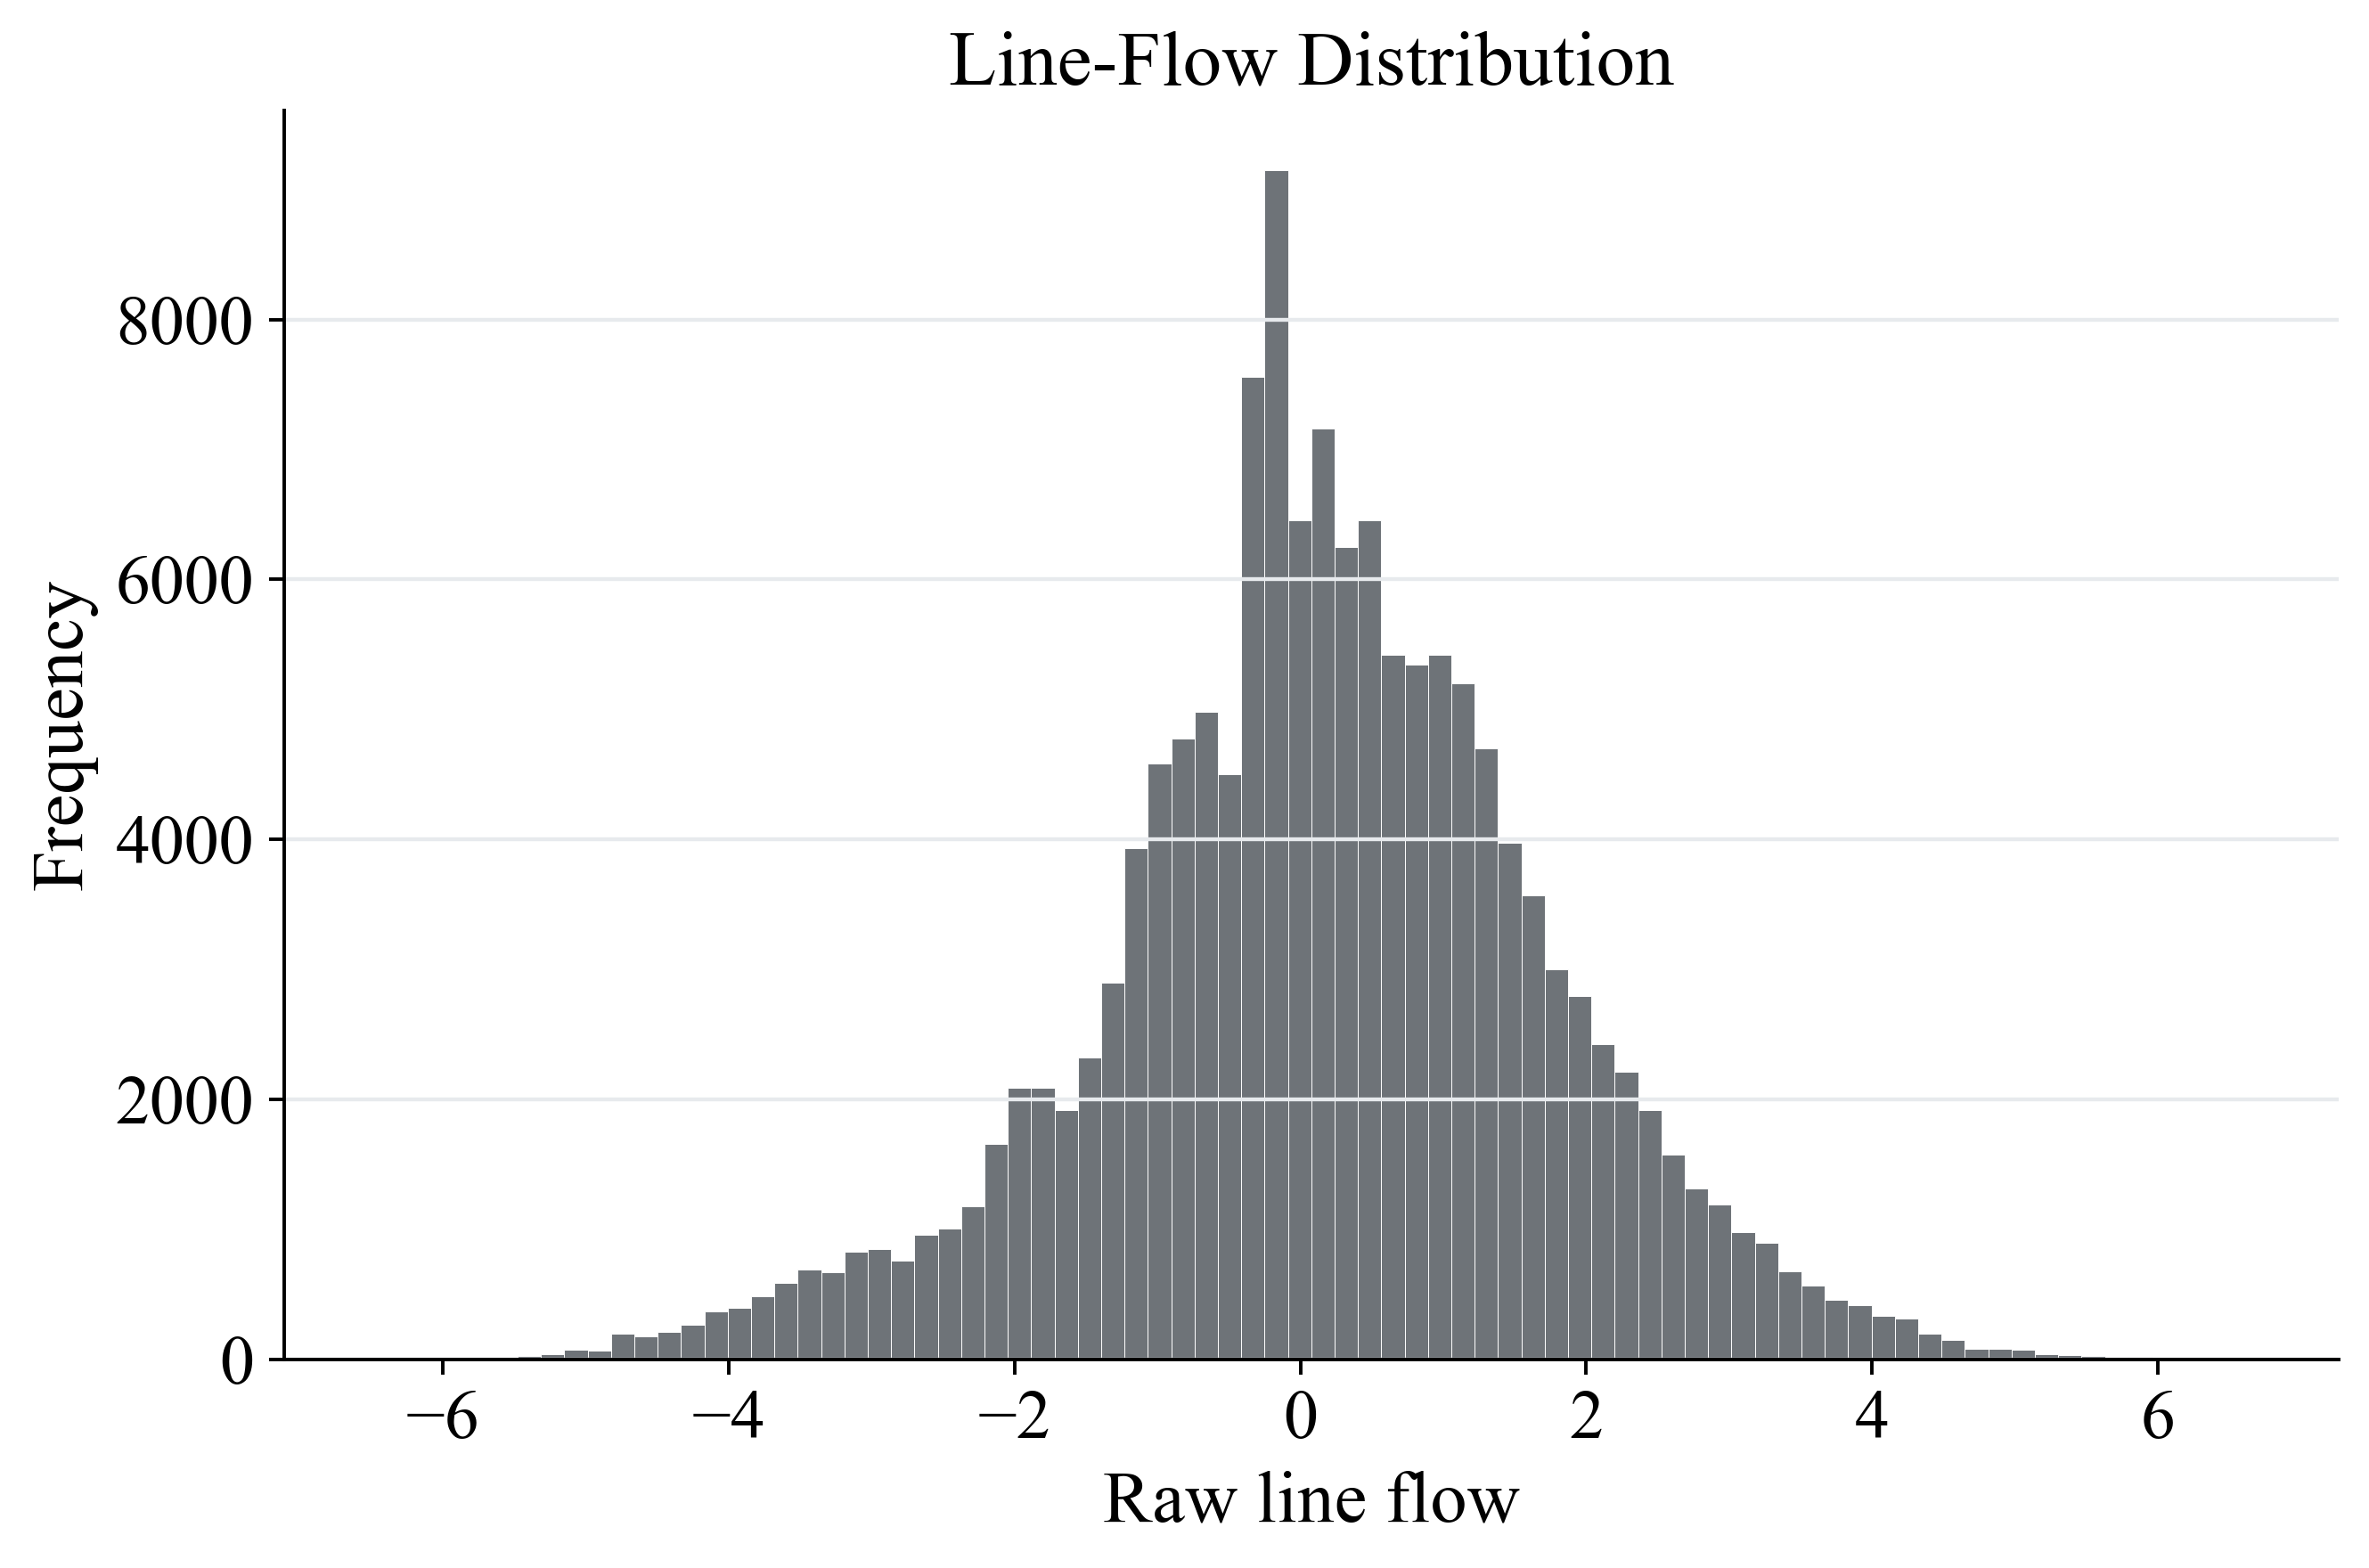

Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Figures/fig_03_raw_line_flow_distribution.png


In [6]:
coverage = file_summary.groupby("kind").agg(files=("file", "count"), rows=("rows", "sum"), columns=("columns", "mean"), bytes=("size_bytes", "sum")).reset_index()
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(coverage["kind"], coverage["rows"] / 1e6, color=[PALETTE["blue"], PALETTE["teal"], PALETTE["purple"]])
ax.set_title("Transmission Grid Data Coverage")
ax.set_ylabel("Rows across matched files (millions)")
ax.grid(axis="y", color=PALETTE["light_gray"], linewidth=0.9)
for bar, value in zip(bars, coverage["rows"] / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom", fontsize=16)
fig.savefig(FIGURES / "fig_01_data_coverage.png", dpi=350, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIGURES / "fig_01_data_coverage.png")

plot_components = network_component_summary[network_component_summary["component"].isin(["bus", "branch", "gen", "load"])]
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(plot_components["component"], plot_components["count"], color=PALETTE["blue"])
ax.set_title("Graph Topology Summary")
ax.set_ylabel("Component count")
ax.grid(axis="y", color=PALETTE["light_gray"], linewidth=0.9)
for bar, value in zip(bars, plot_components["count"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{int(value):,}", ha="center", va="bottom", fontsize=16)
fig.savefig(FIGURES / "fig_02_network_component_summary.png", dpi=350, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIGURES / "fig_02_network_component_summary.png")

line_sample_path = sorted((DATA_RAW / "lines_2020").glob("lines_2020_1.csv"))[0]
line_sample = pd.read_csv(line_sample_path, nrows=1200, usecols=lambda c: int(c) <= 120, dtype=np.float32)
vals = line_sample.to_numpy(dtype=np.float32).ravel()
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.hist(vals[np.isfinite(vals)], bins=80, color=PALETTE["gray"], edgecolor=PALETTE["white"], linewidth=0.2)
ax.set_title("Line-Flow Distribution")
ax.set_xlabel("Raw line flow")
ax.set_ylabel("Frequency")
ax.grid(axis="y", color=PALETTE["light_gray"], linewidth=0.9)
fig.savefig(FIGURES / "fig_03_raw_line_flow_distribution.png", dpi=350, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", FIGURES / "fig_03_raw_line_flow_distribution.png")

## Research Design and Leakage Controls

The design uses matched suffix groups from 2020. Suffix groups 1-3 are split chronologically into train, validation, and test partitions; suffix group 4 is reserved as a held-out external-test group. Thresholds, selected lines, scalers, calibration functions, and ablation decisions are derived only from training and validation partitions.

In [7]:
research_scope = pd.DataFrame([
    {"item": "Primary objective", "definition": "Probabilistic overload-risk forecasting and line-flow forecasting for selected critical transmission lines."},
    {"item": "Task A", "definition": "Overload risk classification using Normal, Warning, and Critical labels; binary Critical risk is used for calibrated probabilistic comparison."},
    {"item": "Task B", "definition": "Line-flow forecasting with point and probabilistic interval outputs for 1 h and 6 h horizons, with 24 h targets prepared when feasible."},
    {"item": "Research gap", "definition": "Most forecasting studies treat line-flow prediction, topology, uncertainty, calibration, and external-year or external-group robustness separately."},
    {"item": "Proposed contribution", "definition": "B-TGPRF integrates temporal dynamics, topology-aware graph features, Bayesian posterior risk estimation, conformal intervals, residual correction, and external testing."},
])
research_scope.to_csv(TABLES / "research_scope_summary.csv", index=False)

split_protocol = pd.DataFrame([
    {"partition": "train", "suffix_groups": "2020 groups 1-3", "time_rule": "first 60% within each group", "allowed_use": "model fitting, line selection, train thresholds"},
    {"partition": "validation", "suffix_groups": "2020 groups 1-3", "time_rule": "next 20% within each group", "allowed_use": "hyperparameter selection, calibration, threshold selection"},
    {"partition": "test", "suffix_groups": "2020 groups 1-3", "time_rule": "final 20% within each group", "allowed_use": "final internal evaluation only"},
    {"partition": "external_test", "suffix_groups": "2020 group 4", "time_rule": "all valid target times", "allowed_use": "external-like robustness evaluation only"},
])
split_protocol.to_csv(TABLES / "split_protocol_summary.csv", index=False)

leakage_controls = pd.DataFrame([
    {"risk": "Future target leakage", "control": "Future line-flow targets are produced by group-wise forward shifts after sorting by suffix, line, and time."},
    {"risk": "Threshold leakage", "control": "Risk thresholds and critical-line selection use training rows only."},
    {"risk": "Temporal leakage", "control": "Lag and rolling features use shifted historical values only."},
    {"risk": "External-test leakage", "control": "Suffix group 4 is never used for fitting, calibration, feature selection, or ablation decisions."},
    {"risk": "Test tuning", "control": "Only validation data are used for hyperparameter and decision-threshold selection."},
])
leakage_controls.to_csv(TABLES / "leakage_control_summary.csv", index=False)

display(research_scope)
display(split_protocol)
display(leakage_controls)

experiment_config = {
    "title": "Bayesian Temporal Graph Transformer for Probabilistic Overload Risk Forecasting in Power Transmission Grids",
    "dataset_record": f"https://zenodo.org/records/{RECORD_ID}",
    "years_used": YEARS,
    "multi_year_enabled": ENABLE_MULTIYEAR,
    "matched_suffix_groups": pivot[pivot["matched_load_gen_line_group"]][["year", "suffix"]].to_dict("records"),
    "selected_line_count_default": 100,
    "debug_line_count": 20,
    "forecast_horizons_hours": [1, 6, 24],
    "risk_thresholds": [0.90, 0.95, 0.99],
    "primary_critical_threshold": "line-specific 95th percentile of training absolute flow",
    "split_protocol": split_protocol.to_dict("records"),
    "random_seed": RANDOM_SEED,
    "classical_environment": "ai-classic-ml-cpu",
    "deep_learning_environment": "ai-pytorch-mps",
}
with open(REPORTS / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)
print("Saved:", REPORTS / "experiment_config.json")

,item,definition
0,Primary objective,Probabilistic overload-risk forecasting and li...
1,Task A,"Overload risk classification using Normal, War..."
2,Task B,Line-flow forecasting with point and probabili...
3,Research gap,Most forecasting studies treat line-flow predi...
4,Proposed contribution,"B-TGPRF integrates temporal dynamics, topology..."


,partition,suffix_groups,time_rule,allowed_use
0,train,2020 groups 1-3,first 60% within each group,"model fitting, line selection, train thresholds"
1,validation,2020 groups 1-3,next 20% within each group,"hyperparameter selection, calibration, thresho..."
2,test,2020 groups 1-3,final 20% within each group,final internal evaluation only
3,external_test,2020 group 4,all valid target times,external-like robustness evaluation only


,risk,control
0,Future target leakage,Future line-flow targets are produced by group...
1,Threshold leakage,Risk thresholds and critical-line selection us...
2,Temporal leakage,Lag and rolling features use shifted historica...
3,External-test leakage,"Suffix group 4 is never used for fitting, cali..."
4,Test tuning,Only validation data are used for hyperparamet...


Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Reports/experiment_config.json


## Audit Report and Architecture Diagram

The audit report documents the validated dataset state and modelling design. A draw.io-compatible architecture file and a rendered preview are created for manuscript and presentation use.

Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Reports/dataset_audit_report.md
Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Bayesian_PowerGrid_Risk_Forecasting_pipeline_and_architecture.drawio


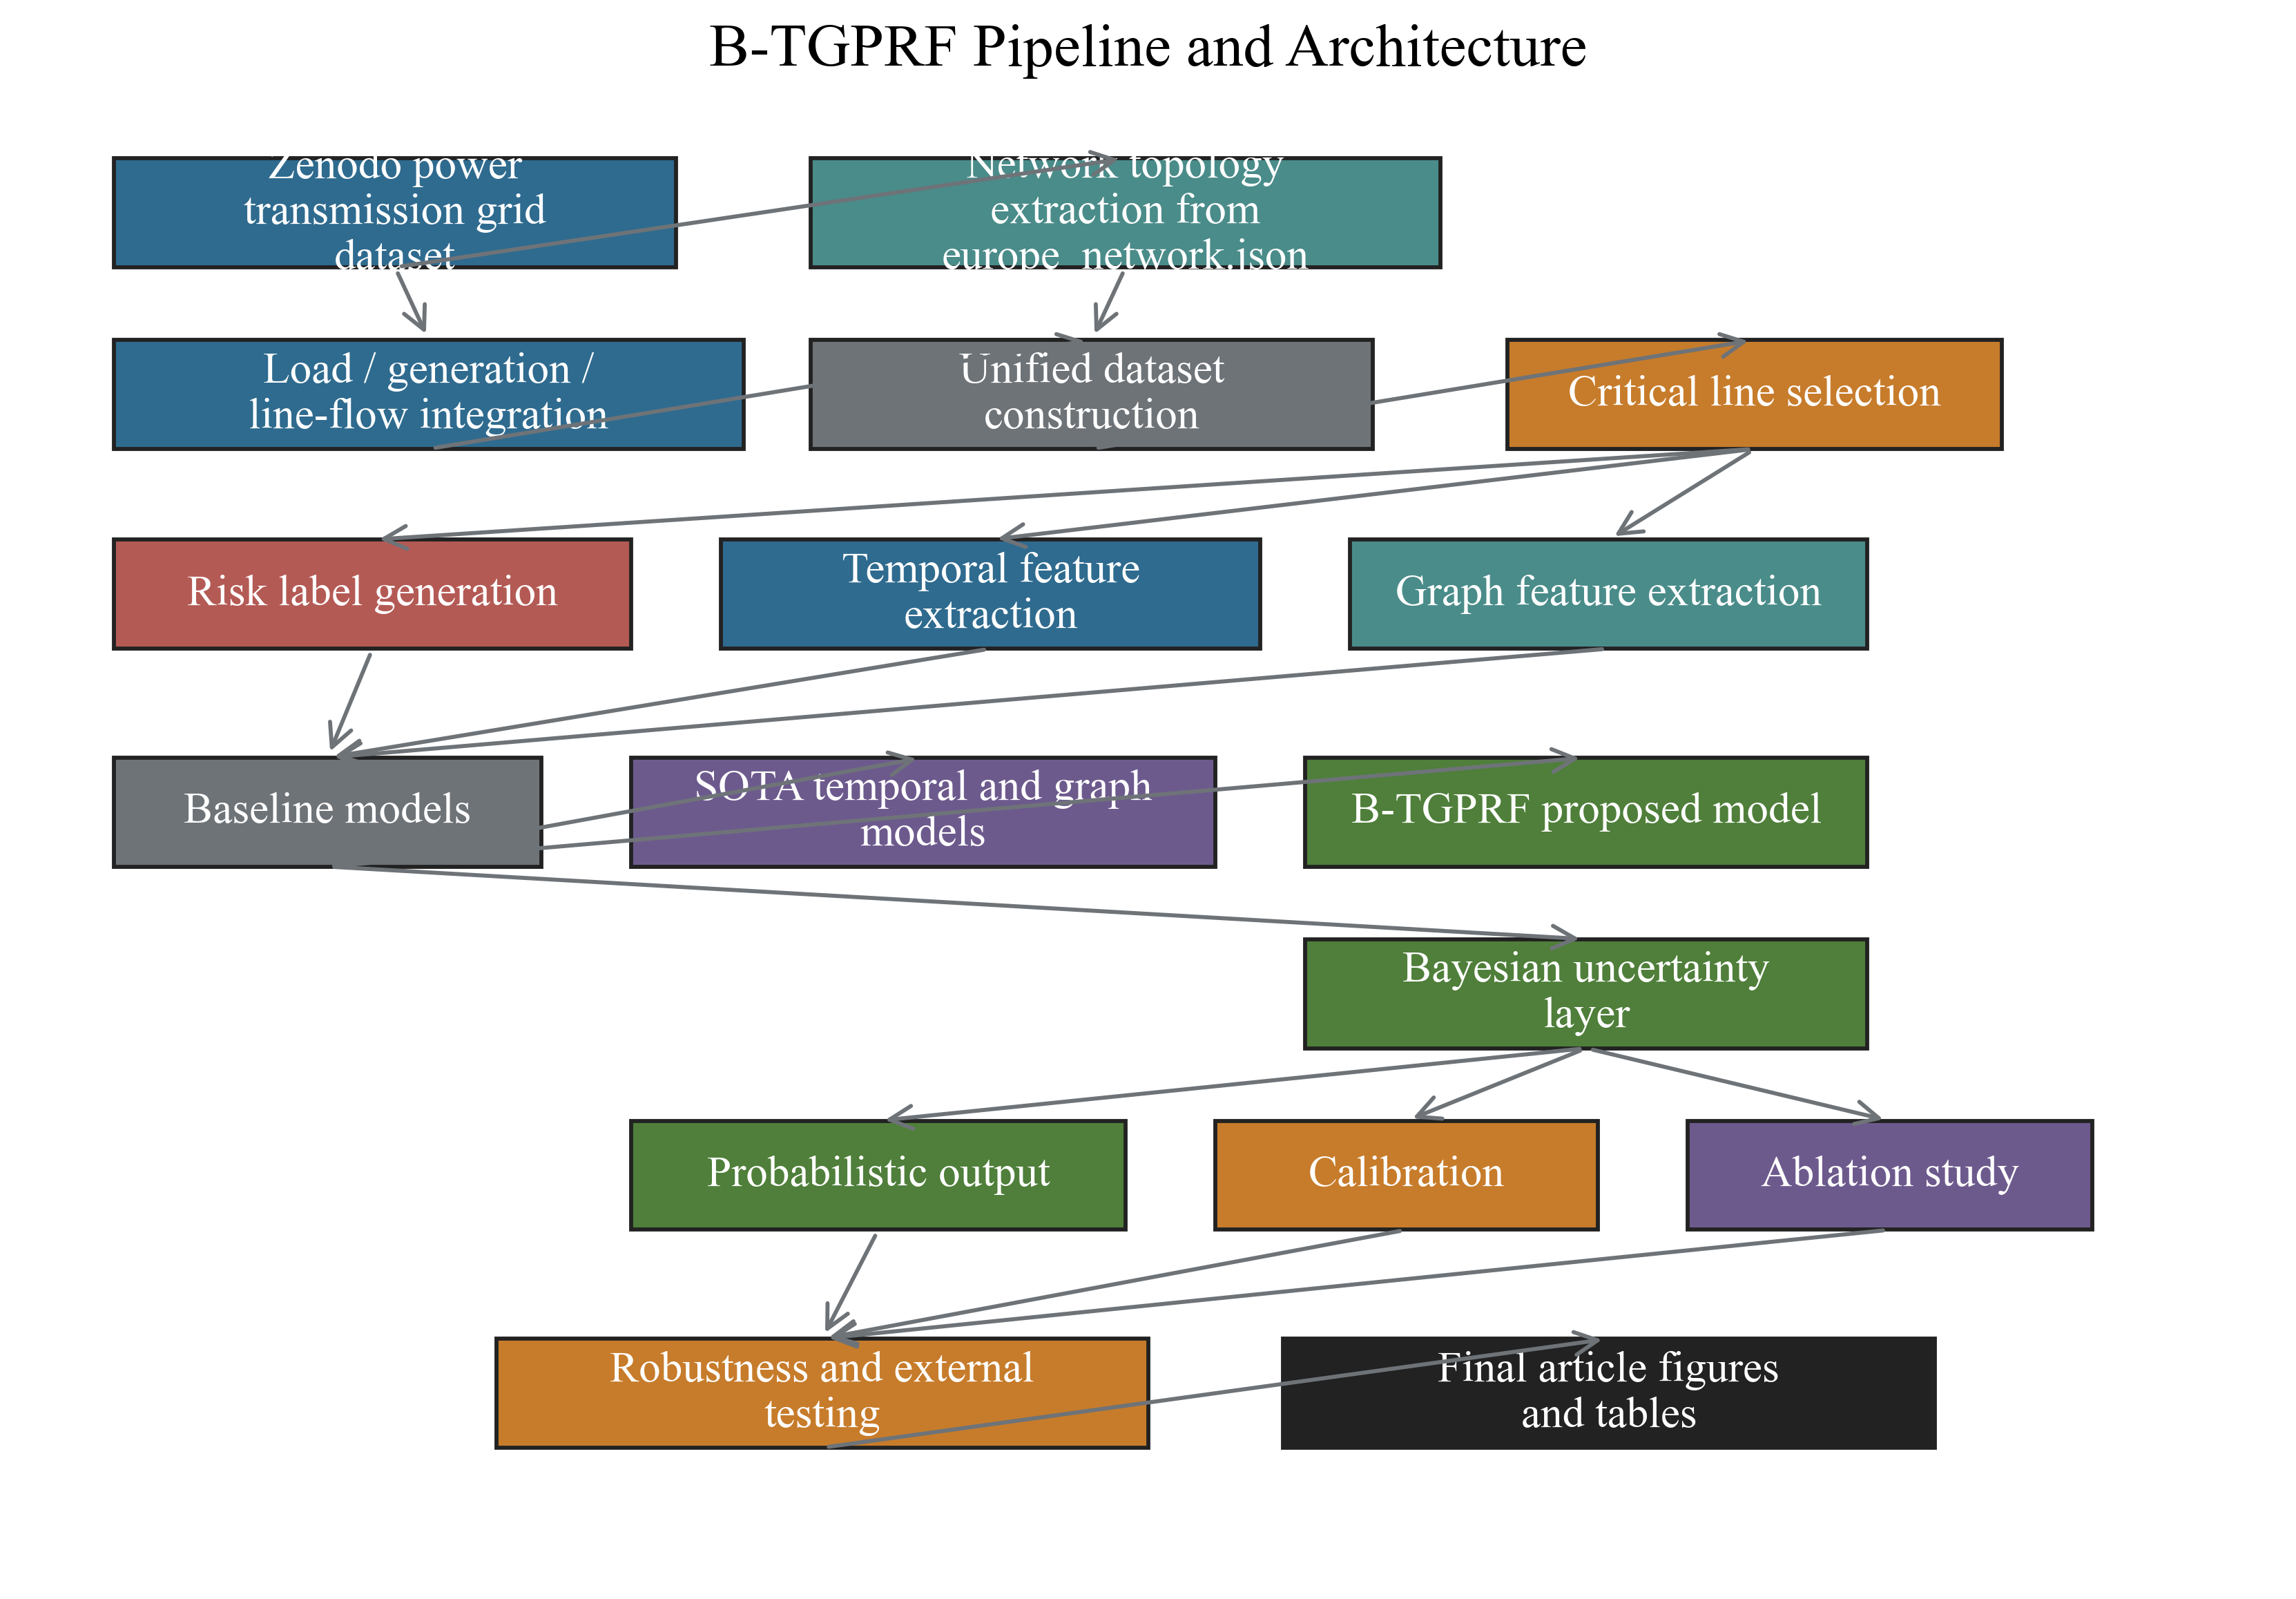

Saved: /Users/talgatazykanov/Desktop/Science works/Bayiessian_Asem_Almaty_2026_05/Bayesian_PowerGrid_Risk_Forecasting_N1/Drawio_Preview/pipeline_architecture_preview.png


In [8]:
audit_md = f"""# Dataset Audit Report

## Dataset Source
- Zenodo record: https://zenodo.org/records/{RECORD_ID}
- Files used in this executable protocol: {', '.join(required_files)}
- Multi-year extension: disabled in this run because the 2020 archives are already large and contain four matched scenario suffix groups.

## File Audit
{file_summary.to_string(index=False)}

## Matched Groups
{pivot.to_string(index=False)}

## Network Components
{network_component_summary.to_string(index=False)}

## Leakage Controls
{leakage_controls.to_string(index=False)}
"""
(REPORTS / "dataset_audit_report.md").write_text(audit_md)
print("Saved:", REPORTS / "dataset_audit_report.md")

# Valid draw.io XML with a compact pipeline and architecture overview.
diagram_cells = [
    ("Zenodo power transmission grid dataset", 40, 40, 250, 60, PALETTE["blue"]),
    ("Network topology extraction from europe_network.json", 350, 40, 280, 60, PALETTE["teal"]),
    ("Load / generation / line-flow integration", 40, 140, 280, 60, PALETTE["blue"]),
    ("Unified dataset construction", 350, 140, 250, 60, PALETTE["gray"]),
    ("Critical line selection", 660, 140, 220, 60, PALETTE["orange"]),
    ("Risk label generation", 40, 250, 230, 60, PALETTE["red"]),
    ("Temporal feature extraction", 310, 250, 240, 60, PALETTE["blue"]),
    ("Graph feature extraction", 590, 250, 230, 60, PALETTE["teal"]),
    ("Baseline models", 40, 370, 190, 60, PALETTE["gray"]),
    ("SOTA temporal and graph models", 270, 370, 260, 60, PALETTE["purple"]),
    ("B-TGPRF proposed model", 570, 370, 250, 60, PALETTE["green"]),
    ("Bayesian uncertainty layer", 570, 470, 250, 60, PALETTE["green"]),
    ("Probabilistic output", 270, 570, 220, 60, PALETTE["green"]),
    ("Calibration", 530, 570, 170, 60, PALETTE["orange"]),
    ("Ablation study", 740, 570, 180, 60, PALETTE["purple"]),
    ("Robustness and external testing", 210, 690, 290, 60, PALETTE["orange"]),
    ("Final article figures and tables", 560, 690, 290, 60, PALETTE["black"]),
]
mx_cells = []
for idx, (label, x, y, w, h, color) in enumerate(diagram_cells, start=2):
    style = f"rounded=1;whiteSpace=wrap;html=1;fillColor={color};fontColor=#FFFFFF;strokeColor=#222222;"
    mx_cells.append(f'<mxCell id="{idx}" value="{label}" style="{style}" vertex="1" parent="1"><mxGeometry x="{x}" y="{y}" width="{w}" height="{h}" as="geometry"/></mxCell>')
edge_pairs = [(2,3),(2,4),(3,5),(4,5),(5,6),(6,7),(6,8),(6,9),(7,10),(8,10),(9,10),(10,11),(10,12),(10,13),(13,14),(13,15),(13,16),(14,17),(15,17),(16,17),(17,18)]
for eidx, (src, tgt) in enumerate(edge_pairs, start=100):
    mx_cells.append(f'<mxCell id="{eidx}" style="edgeStyle=orthogonalEdgeStyle;rounded=0;orthogonalLoop=1;jettySize=auto;html=1;strokeColor=#6E7378;" edge="1" parent="1" source="{src}" target="{tgt}"><mxGeometry relative="1" as="geometry"/></mxCell>')
xml = '<?xml version="1.0" encoding="UTF-8"?><mxfile host="app.diagrams.net"><diagram name="B-TGPRF Pipeline"><mxGraphModel dx="1200" dy="900" grid="1" gridSize="10" guides="1" tooltips="1" connect="1" arrows="1" fold="1" page="1" pageScale="1" pageWidth="1000" pageHeight="850" math="0" shadow="0"><root><mxCell id="0"/><mxCell id="1" parent="0"/>' + ''.join(mx_cells) + '</root></mxGraphModel></diagram></mxfile>'
(PROJECT_ROOT / "Bayesian_PowerGrid_Risk_Forecasting_pipeline_and_architecture.drawio").write_text(xml)
print("Saved:", PROJECT_ROOT / "Bayesian_PowerGrid_Risk_Forecasting_pipeline_and_architecture.drawio")

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 1000); ax.set_ylim(820, 0); ax.axis("off")
for label, x, y, w, h, color in diagram_cells:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=PALETTE["black"], linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, textwrap.fill(label, 24), ha="center", va="center", color="white", fontsize=13)
for src, tgt in edge_pairs:
    s = diagram_cells[src-2]; t = diagram_cells[tgt-2]
    sx, sy = s[1]+s[3]/2, s[2]+s[4]
    tx, ty = t[1]+t[3]/2, t[2]
    ax.annotate("", xy=(tx, ty), xytext=(sx, sy), arrowprops=dict(arrowstyle="->", color=PALETTE["gray"], lw=1.2))
ax.set_title("B-TGPRF Pipeline and Architecture", fontsize=18)
preview_path = PROJECT_ROOT / "Drawio_Preview" / "pipeline_architecture_preview.png"
fig.savefig(preview_path, dpi=350, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", preview_path)